
--- kappa1 = 0.500000 ---
Number of minima = 4
  minimum 1: (-1.014113, -0.973830), V = -1.402003035155
  minimum 2: (-1.030543,  0.769915), V = -0.871625763088
  minimum 3: ( 0.869708, -0.999405), V = -0.454523503960
  minimum 4: ( 0.891142,  0.809920), V =  0.094291653135
  True vacuum : (-1.014113, -0.973830), V = -1.402003035155
  False vacuum: (-1.030543,  0.769915), V = -0.871625763088
  Delta V     =  0.530377272067
  Distance    =  1.743823
Path deformation converged. 12 steps. fRatio = 1.46778e-02
Path deformation converged. 1 steps. fRatio = 9.29446e-03
  Action      =  35.179196189497

--- kappa1 = 0.525000 ---
Number of minima = 4
  minimum 1: (-1.017019, -0.973270), V = -1.452392241407
  minimum 2: (-1.033380,  0.769004), V = -0.922424839678
  minimum 3: ( 0.865005, -1.000164), V = -0.457839408062
  minimum 4: ( 0.886675,  0.811060), V =  0.091514521895
  True vacuum : (-1.017019, -0.973270), V = -1.452392241407
  False vacuum: (-1.033380,  0.769004), V = -0.922424839678


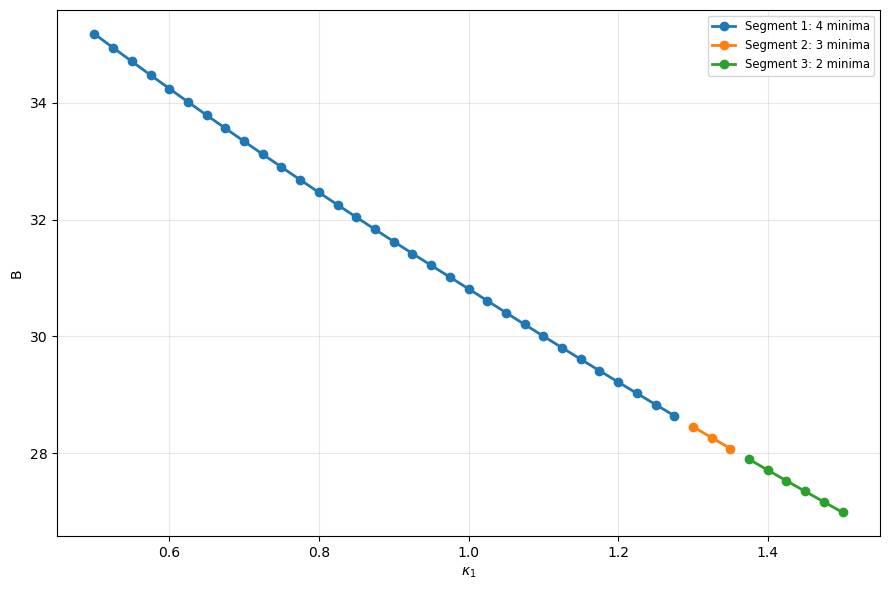


Runtime: 34.220388 seconds


In [4]:

#__________________________________Action vs Kappa1___________________________

import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from cosmoTransitions import pathDeformation as pd


class TwoDimColemanPotential:
    r"""
    Dimensionless potential:
        v(x,y) =
            (x^2 - 1)^2
          + kappa1 (x - 1)
          + rho (y^2 - 1)^2
          + rho*kappa2 (y - 1)
          + gamma x^2 y^2
    """

    def __init__(self, kappa1=0.7, rho=0.5, kappa2=0.6, gamma=0.2):
        self.kappa1 = kappa1
        self.rho = rho
        self.kappa2 = kappa2
        self.gamma = gamma

    def V(self, X):
        X = np.asanyarray(X)
        x, y = X[..., 0], X[..., 1]
        return (
            (x**2 - 1.0)**2
            + self.kappa1 * (x - 1.0)
            + self.rho * (y**2 - 1.0)**2
            + self.rho * self.kappa2 * (y - 1.0)
            + self.gamma * x**2 * y**2
        )

    def dV(self, X):
        X = np.asanyarray(X)
        x, y = X[..., 0], X[..., 1]

        dVdx = 4.0 * x * (x**2 - 1.0) + self.kappa1 + 2.0 * self.gamma * x * y**2
        dVdy = 4.0 * self.rho * y * (y**2 - 1.0) + self.rho * self.kappa2 + 2.0 * self.gamma * x**2 * y

        out = np.empty_like(X)
        out[..., 0] = dVdx
        out[..., 1] = dVdy
        return out

    def hessian_num(self, x, h=1e-5):
        x = np.asarray(x, dtype=float)
        H = np.zeros((2, 2), dtype=float)

        e1 = np.array([1.0, 0.0])
        e2 = np.array([0.0, 1.0])

        H[0, 0] = (self.V(x + h * e1) - 2 * self.V(x) + self.V(x - h * e1)) / h**2
        H[1, 1] = (self.V(x + h * e2) - 2 * self.V(x) + self.V(x - h * e2)) / h**2
        H[0, 1] = H[1, 0] = (
            self.V(x + h * e1 + h * e2)
            - self.V(x + h * e1 - h * e2)
            - self.V(x - h * e1 + h * e2)
            + self.V(x - h * e1 - h * e2)
        ) / (4 * h**2)
        return H


def refine_stationary_point(model, guess):
    res = minimize(model.V, guess, jac=model.dV, method="BFGS", tol=1e-12)
    return res.x, res.fun


def classify_point(model, x):
    H = model.hessian_num(x)
    eigs = np.linalg.eigvalsh(H)
    is_min = np.all(eigs > 1e-7)
    return is_min, eigs


def unique_points(points, tol=1e-4):
    uniq = []
    for p in points:
        if not any(np.linalg.norm(p - q) < tol for q in uniq):
            uniq.append(p)
    return uniq


def find_all_minima(model, xlim=(-2, 2), ylim=(-2, 2), ngrid=17):
    xs = np.linspace(xlim[0], xlim[1], ngrid)
    ys = np.linspace(ylim[0], ylim[1], ngrid)

    candidates = []
    for x0 in xs:
        for y0 in ys:
            try:
                p, _ = refine_stationary_point(model, np.array([x0, y0]))
                is_min, _ = classify_point(model, p)
                if is_min:
                    candidates.append(p)
            except Exception:
                pass

    minima = unique_points(candidates, tol=1e-4)

    result = []
    for p in minima:
        val = model.V(p)
        result.append((p, val))

    result.sort(key=lambda item: item[1])
    return result


def choose_closest_false_vacuum(minima):
    """
    True vacuum = global minimum.
    False vacuum = local minimum with smallest Euclidean distance
    to the true vacuum among the remaining minima.
    """
    if len(minima) < 2:
        raise RuntimeError("Need at least two minima for tunneling.")

    true_vacuum, v_true = minima[0]

    candidates = []
    for p, val in minima[1:]:
        dist = np.linalg.norm(p - true_vacuum)
        candidates.append((dist, p, val))

    candidates.sort(key=lambda t: t[0])
    dist, false_vacuum, v_false = candidates[0]

    return true_vacuum, v_true, false_vacuum, v_false, dist


def same_point(p, q, tol=5e-2):
    return np.linalg.norm(np.asarray(p) - np.asarray(q)) < tol


def scan_action_vs_kappa1(
    rho=0.5,
    kappa2=0.6,
    gamma=0.2,
    kappa1_min=0.5,
    kappa1_max=1.5,
    n_kappa1=41,
    xlim=(-2, 2),
    ylim=(-2, 2),
    ngrid=17
):
    kappa1_values = np.linspace(kappa1_min, kappa1_max, n_kappa1)

    results = []

    for kappa1 in kappa1_values:
        print(f"\n--- kappa1 = {kappa1:.6f} ---")
        model = TwoDimColemanPotential(
            kappa1=kappa1,
            rho=rho,
            kappa2=kappa2,
            gamma=gamma
        )

        minima = find_all_minima(model, xlim=xlim, ylim=ylim, ngrid=ngrid)
        nmin = len(minima)

        print(f"Number of minima = {nmin}")
        for i, (p, val) in enumerate(minima, start=1):
            print(f"  minimum {i}: ({p[0]: .6f}, {p[1]: .6f}), V = {val: .12f}")

        if nmin < 2:
            print("  Skipping: fewer than two minima.")
            results.append({
                "kappa1": kappa1,
                "nmin": nmin,
                "action": np.nan,
                "tv": None,
                "fv": None,
                "v_true": np.nan,
                "v_false": np.nan
            })
            continue

        try:
            true_vacuum, v_true, false_vacuum, v_false, dist = choose_closest_false_vacuum(minima)

            print(f"  True vacuum : ({true_vacuum[0]: .6f}, {true_vacuum[1]: .6f}), V = {v_true: .12f}")
            print(f"  False vacuum: ({false_vacuum[0]: .6f}, {false_vacuum[1]: .6f}), V = {v_false: .12f}")
            print(f"  Delta V     = {v_false - v_true: .12f}")
            print(f"  Distance    = {dist: .6f}")

            init_path = [true_vacuum, false_vacuum]
            Y = pd.fullTunneling(init_path, model.V, model.dV)
            action = Y.action

            print(f"  Action      = {action: .12f}")

            results.append({
                "kappa1": kappa1,
                "nmin": nmin,
                "action": action,
                "tv": np.array(true_vacuum),
                "fv": np.array(false_vacuum),
                "v_true": v_true,
                "v_false": v_false
            })

        except Exception as exc:
            print(f"  Solver failed: {exc}")
            results.append({
                "kappa1": kappa1,
                "nmin": nmin,
                "action": np.nan,
                "tv": None,
                "fv": None,
                "v_true": np.nan,
                "v_false": np.nan
            })

    return results


def split_into_segments(results, point_tol=5e-2):
    """
    Start a new curve whenever:
      1) number of minima changes, or
      2) chosen true vacuum changes noticeably, or
      3) chosen false vacuum changes noticeably, or
      4) action is NaN / invalid.
    """
    segments = []
    current = []

    prev = None
    for r in results:
        valid = np.isfinite(r["action"]) and (r["tv"] is not None) and (r["fv"] is not None)

        if not valid:
            if current:
                segments.append(current)
                current = []
            prev = None
            continue

        if prev is None:
            current = [r]
            prev = r
            continue

        changed = False

        if r["nmin"] != prev["nmin"]:
            changed = True
        elif not same_point(r["tv"], prev["tv"], tol=point_tol):
            changed = True
        elif not same_point(r["fv"], prev["fv"], tol=point_tol):
            changed = True

        if changed:
            if current:
                segments.append(current)
            current = [r]
        else:
            current.append(r)

        prev = r

    if current:
        segments.append(current)

    return segments


def plot_action_vs_kappa1(results):
    segments = split_into_segments(results, point_tol=5e-2)

    plt.figure(figsize=(9, 6))

    for i, seg in enumerate(segments, start=1):
        kappa1_values = [r["kappa1"] for r in seg]
        actions = [r["action"] for r in seg]
        nmin = seg[0]["nmin"]

        label = f"Segment {i}: {nmin} minima"
        plt.plot(kappa1_values, actions, marker='o', linewidth=2, label=label)

    plt.xlabel(r"$\kappa_1$")
    plt.ylabel("B")
   # plt.title(r"Action vs $\kappa_1$ for fixed $\rho=0.5,\ \kappa_2=0.6,\ \gamma=0.2$")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize='small')
    plt.tight_layout()

    plt.show()


def main():
    start = time.perf_counter()

    results = scan_action_vs_kappa1(
        rho=0.5,
        kappa2=0.6,
        gamma=0.2,
        kappa1_min=0.5,
        kappa1_max=1.5,
        n_kappa1=41,   # increase for smoother curves
        xlim=(-2, 2),
        ylim=(-2, 2),
        ngrid=17
    )

    print("\n================ SUMMARY ================")
    for r in results:
        if np.isfinite(r["action"]):
            print(
                f"kappa1={r['kappa1']:.6f}, "
                f"nmin={r['nmin']}, "
                f"action={r['action']:.10f}, "
                f"TV=({r['tv'][0]:.6f},{r['tv'][1]:.6f}), "
                f"FV=({r['fv'][0]:.6f},{r['fv'][1]:.6f})"
            )
        else:
            print(
                f"kappa1={r['kappa1']:.6f}, "
                f"nmin={r['nmin']}, action=NaN"
            )

    plot_action_vs_kappa1(results)

    end = time.perf_counter()
    print(f"\nRuntime: {end - start:.6f} seconds")


if __name__ == "__main__":
    main()